# 중복제거와검출평가

예측끼리 중복을 제거하는 알고리즘과 예측·정답을 일대일로 연결하는 알고리즘을 각각 구현합니다.

함수명·입출력·API 예시는 제공합니다. **작성 구간의 처리 로직을 직접 구성하세요.**
검증 셀은 수정하지 않습니다. 파일 안에서는 위에서부터 실행합니다.


In [1]:
from pathlib import Path
import os, sys, json, time

ROOT = Path(r"C:\Users\User\.ngv_day4_2026\pm\1b2d65c48c7e")

sys.path.insert(0,str(ROOT))
os.environ['MPLCONFIGDIR']=str(ROOT/'.runtime/matplotlib')
os.environ['YOLO_CONFIG_DIR']=str(ROOT/'.runtime/yolo')
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance, ImageOps, ImageDraw
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
torch.set_num_threads(4)
plt.rcParams['font.family']='Malgun Gothic'
plt.rcParams['axes.unicode_minus']=False
from ultralytics import YOLO
dataset=ROOT/'dataset_group20_seed42'
if not (dataset/'annotations.json').exists():
    from speed_project import prepare_data
    dataset,_=prepare_data(seed=42)
records=json.loads((dataset/'annotations.json').read_text(encoding='utf-8'))
run=ROOT/'runs/verified'
WEIGHTS=run/'weights/best.pt'


## IoU 재사용 · 제공 코드
01의 완성 코드를 사용합니다. 이번 데이터는 speedlimit 한 종류입니다.


In [2]:
def iou(a,b):
    iw=max(0,min(a[2],b[2])-max(a[0],b[0]))
    ih=max(0,min(a[3],b[3])-max(a[1],b[1]))
    intersection=iw*ih
    area_a=max(0,a[2]-a[0])*max(0,a[3]-a[1])
    area_b=max(0,b[2]-b[0])*max(0,b[3]-b[1])
    union=area_a+area_b-intersection
    return intersection/union if union>0 else 0.


## ✏️ B03 · NMS 알고리즘 구성

입력: 박스 목록, 같은 순서의 점수, IoU 기준. 반환: 남길 원래 박스 번호 목록.
가장 높은 점수부터 선택하고, 선택한 박스와 IoU가 기준보다 큰 후보를 제거합니다. 남은 후보에 반복합니다.
동점은 원래 순서이며 빈 입력은 빈 목록입니다. 정답 박스는 사용하지 않습니다.

### 사용할 수 있는 API
`np.argsort(-np.asarray(scores),kind="stable")`, 리스트 `.pop`, `.append`, 앞 셀 `iou(a,b)`.
예: `items=[4,7]; value=items.pop(0)`이면 value는 4, items는 [7].


### 처리 단계 힌트
1. 후보 번호를 점수 순서로 정렬합니다.
2. 첫 번호를 결과로 옮깁니다.
3. 선택한 박스와 겹치는 후보만 제외합니다.
4. 남은 후보가 없을 때까지 반복합니다.

**작은 예시** · 분리된 두 박스의 점수가 `[0.3,0.9]`이면 반환 번호는 `[1,0]`입니다.


In [3]:
# ===== 실습 B03 시작 =====

def my_nms(boxes,scores,threshold):
    order=np.argsort(-np.asarray(scores),kind='stable').tolist();kept=[]
    while order:
        chosen=order.pop(0);kept.append(chosen)
        order=[i for i in order if iou(boxes[chosen],boxes[i])<=threshold]
    return kept
    raise NotImplementedError('B03: 정렬·선택·제거 반복 구성')

# ===== 실습 B03 끝 =====


**B03 검증** · 아래 셀이 통과한 뒤 실제 데이터에 적용합니다.


In [4]:
boxes=[[20,20,30,30],[0,0,10,10],[0,0,10,10]];scores=[.3,.6,.9]
assert my_nms(boxes,scores,.5)==[2,0],'B03: 점수 정렬과 중복 제거를 확인하세요.'
assert my_nms(boxes,scores,1.)==[2,1,0]
assert my_nms([[0,0,10,10],[0,0,10,10]],[.8,.8],.5)==[0]
assert my_nms([],[],.5)==[]
assert my_nms([[0,0,10,10],[2,0,12,10],[4,0,14,10]],[.9,.8,.7],.5)==[0,2],'B03: 제거한 후보를 기준으로 다시 제거하지 마세요.'
print('B03 통과: 정렬·중복·경계값·동점·빈 입력')


B03 통과: 정렬·중복·경계값·동점·빈 입력


## 실제 후보에서 NMS 비교 · 제공 코드
점수 0.25 이상·상위 100개로 수집한 후보입니다. 0.99는 중복을 보여주기 위한 극단값입니다.


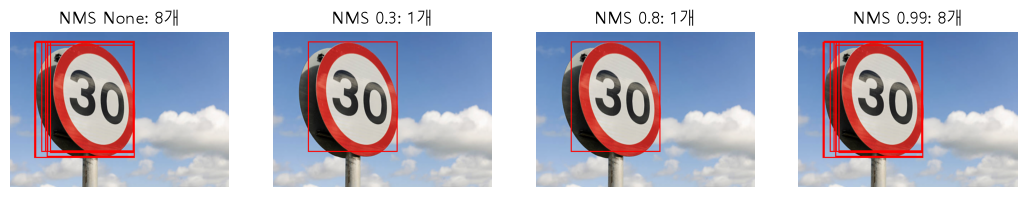

In [5]:
path=sorted((dataset/'images/val').glob('*.png'))[0]
detector=YOLO(str(WEIGHTS));result=detector.predict(str(path),imgsz=320,conf=.25,iou=1.,max_det=100,device='cpu',verbose=False)[0]
boxes=result.boxes.xyxy.tolist();scores=result.boxes.conf.tolist();image=Image.open(path).convert('RGB')
fig,axes=plt.subplots(1,4,figsize=(13,4))
for ax,threshold in zip(axes,[None,.3,.8,.99]):
    ids=list(range(len(boxes))) if threshold is None else my_nms(boxes,scores,threshold)
    im=image.copy();d=ImageDraw.Draw(im)
    for i in ids:d.rectangle(boxes[i],outline='red',width=2)
    ax.imshow(im);ax.axis('off');ax.set_title(f'NMS {threshold}: {len(ids)}개')
plt.show()


## ✏️ B04 · 예측과 정답의 일대일 매칭

entry는 `gt`, `boxes`, `scores`를 가진 사전입니다. 같은 클래스만 포함합니다.
점수 기준 이상인 예측을 점수 내림차순으로 처리합니다. 아직 연결되지 않은 정답 중 IoU가 가장 큰 것을 찾아, IoU 기준 이상일 때 연결합니다.
정답 하나는 한 번만 사용합니다. 반환: `(예측 원래 번호, 각 예측의 연결 성공 여부, 놓친 정답 번호)`.

### 사용할 수 있는 API
`set()`과 `.add`, `np.argsort`, `max(items,key=...)`, `iou`.
예: `max([2,5,1],key=lambda x:-x)`는 비교 기준을 지정하는 문법입니다.
정답이 없을 때, 예측이 없을 때도 처리하세요.


### 처리 단계 힌트
1. 점수 기준을 통과한 예측 번호를 정렬합니다.
2. 이미 연결한 정답 번호를 집합으로 관리합니다.
3. 각 예측에서 사용하지 않은 정답의 IoU를 비교합니다.
4. 연결 성공 여부와 끝까지 남은 정답을 반환합니다.

**작은 예시** · 정답 한 개에 동일한 예측 두 개(점수 0.9, 0.8)가 있으면 `([0,1], [True,False], [])`입니다.


In [9]:
# ===== 실습 B04 시작 =====

def match(entry, conf=0.25, iou_threshold=0.5):
    # 1. 신뢰도 점수(scores)를 가져와 배열로 변환
    scores = np.asarray(entry['scores'])
    
    # 2. 임계값(conf) 이상인 인덱스만 필터링하여 점수 기준 내림차순 정렬
    # (argsort는 오름차순이므로 [::-1]로 뒤집어 내림차순으로 만듭니다)
    sorted_indices = np.argsort(scores, kind='stable')[::-1]
    order = [int(i) for i in sorted_indices if scores[i] >= conf]
    
    used = set()
    hits = []
    
    # 3. 예측 박스를 순회하며 GT 박스와 매칭
    for i in order:
        remaining = [j for j in range(len(entry['gt'])) if j not in used]
        
        if remaining:
            # 남은 GT 중 IoU가 가장 높은 GT 박스의 인덱스를 찾음
            j = max(remaining, key=lambda j: iou(entry['boxes'][i], entry['gt'][j]))
            # 해당 IoU가 기준치(iou_threshold) 이상인지 확인
            ok = (j is not None) and (iou(entry['boxes'][i], entry['gt'][j]) >= iou_threshold)
        else:
            j = None
            ok = False
            
        if ok:
            used.add(j)
            hits.append(True)
        else:
            hits.append(False)
            
    # 4. 매칭되지 않고 남은 GT 박스의 인덱스 목록 생성
    unmatched_gt = [j for j in range(len(entry['gt'])) if j not in used]
    
    return order, hits, unmatched_gt
   # raise NotImplementedError('B04: 사용한 정답을 관리하며 매칭')

# ===== 실습 B04 끝 =====


**B04 검증** · 아래 셀이 통과한 뒤 실제 데이터에 적용합니다.


In [10]:
e={'gt':[[0,0,10,10],[20,20,30,30]],'boxes':[[0,0,10,10],[0,0,10,10],[20,20,30,30]],'scores':[.8,.9,.1]}
assert match(e)==([1,0],[True,False],[1]),'B04: 한 정답에 여러 예측을 연결하면 안 됩니다.'
assert match({'gt':[],'boxes':[[0,0,10,10]],'scores':[.9]})==([0],[False],[])
assert match({'gt':[[0,0,10,10]],'boxes':[],'scores':[]})==([],[],[0])
e={'gt':[[0,0,10,10],[5,0,15,10]],'boxes':[[5,0,15,10],[0,0,10,10]],'scores':[.9,.8]}
assert match(e)==([0,1],[True,True],[]),'B04: 첫 번째 정답이 아니라 최대 IoU 정답을 선택하세요.'
assert match({'gt':[[0,0,10,10]],'boxes':[[5,0,15,10]],'scores':[.9]},iou_threshold=.5)==([0],[False],[0])
print('B04 통과: 점수 순서·최대 IoU·일대일·빈 입력·기준')


B04 통과: 점수 순서·최대 IoU·일대일·빈 입력·기준


## 작성한 매칭으로 실제 성능 평가 · 제공 코드
TP=연결된 예측, FP=연결되지 않은 예측, FN=남은 정답입니다. 집계·그림은 제공합니다.


검증 전체: {'TP': 102, 'FP': 11, 'FN': 6, 'precision': 0.9026548672566371, 'recall': 0.9444444444444444, 'F1': 0.9230769230769231}


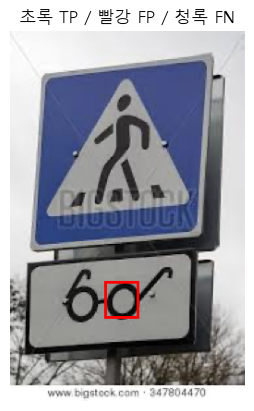

In [11]:
def metrics(entries,conf=.25):
    tp=fp=fn=0
    for e in entries:
        order,hits,miss=match(e,conf)
        tp+=sum(hits);fp+=len(hits)-sum(hits);fn+=len(miss)
    p=tp/max(tp+fp,1);r=tp/max(tp+fn,1)
    return dict(TP=tp,FP=fp,FN=fn,precision=p,recall=r,F1=2*p*r/max(p+r,1e-12))
def collect(weights,dataset,imgsz=320,split='val',limit=None):
    model=YOLO(str(weights))
    records=json.loads((dataset/'annotations.json').read_text())
    paths=sorted((dataset/'images'/split).glob('*.png'))
    if limit is not None:paths=paths[:limit]
    if not paths:raise ValueError('평가 이미지가 없습니다.')
    model.predict(str(paths[0]),imgsz=imgsz,device='cpu',conf=.001,iou=.7,verbose=False)
    entries=[];times=[]
    for p in paths:
        start=time.perf_counter()
        r=model.predict(str(p),imgsz=imgsz,device='cpu',conf=.001,iou=.7,verbose=False)[0]
        times.append((time.perf_counter()-start)*1000)
        entries.append({'image':p.name,'gt':records[p.name]['boxes'],'boxes':r.boxes.xyxy.tolist(),'scores':r.boxes.conf.tolist()})
    return entries,{'mean_ms':float(np.mean(times)),'n':len(paths),'imgsz':imgsz,'split':split}


entries,_=collect(WEIGHTS,dataset,imgsz=320,split='val')
print('검증 전체:',metrics(entries))
from speed_project import metrics as reference_metrics
reference=reference_metrics(entries,.25)
assert all(np.isclose(v,reference[k]) for k,v in metrics(entries).items())
error=next((e for e in entries if not all(match(e)[1]) or match(e)[2]),None)
if error:
    order,hits,miss=match(error);im=Image.open(dataset/'images/val'/error['image']).convert('RGB');d=ImageDraw.Draw(im)
    for i,ok in zip(order,hits):d.rectangle(error['boxes'][i],outline='lime' if ok else 'red',width=3)
    for i in miss:d.rectangle(error['gt'][i],outline='cyan',width=3)
    plt.imshow(im);plt.axis('off');plt.title('초록 TP / 빨강 FP / 청록 FN');plt.show()
